In [8]:
import duckdb
from functions.evaluation import evaluate
from networks.oligoclonal_network import OligoclonalModel
from networks.oligoclonal_network import build_dataloader


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.8).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan oligoklonalt-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med oligoklonalt i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
train_dl = build_dataloader(train_rows)
val_dl = build_dataloader(val_rows)
test_dl = build_dataloader(test_rows)
Oligoclonal.retrain(train_dl=train_dl,val_dl=val_dl,patience=50)

Antal utan oligoklonalt-komponent i träningsdatan: 12830
Antal med oligoklonalt i träningsdatan: 2333
Epoch   0 | train: 0.3597 | val: 0.3244 | acc: 86.62% | AUC: 0.945  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   1 | train: 0.3106 | val: 0.3039 | acc: 86.50% | AUC: 0.950  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   2 | train: 0.3018 | val: 0.2699 | acc: 89.14% | AUC: 0.950  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   3 | train: 0.2957 | val: 0.2779 | acc: 88.71% | AUC: 0.951  | LR: 0.001
Epoch   4 | train: 0.2939 | val: 0.2572 | acc: 90.69% | AUC: 0.950  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model.pth
Epoch   5 | train: 0.2928 | val: 0.2673 | acc: 89.68% | AUC: 0.947  | LR: 0.001
Epoch   6 | train: 0.2900 | val: 0.3526 | acc: 83.40% | AUC: 0.949  | LR: 0.001
Epoch   7 | train: 0.2855 | val: 0.3476 | acc: 82.80% | AUC: 0.951  | LR: 0.00

In [5]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, interpretation,label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

correct_label = df['label'] == 6

valid_text = df['interpretation'].apply(lambda x: 1 if 'oligoklonal' in str(x).lower() else 0)
df['label'] = ((correct_label) | (valid_text)).astype(int)



k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.8).index
k_fold_rows = k_fold_rows.drop(drop_indices)

print(f"Totalt antal utan oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med oligoklonalt i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

Oligoclonal = OligoclonalModel()
Oligoclonal.retrain_with_k_fold(k_fold_rows)

Totalt antal utan oligoklonalt i K-fold poolen: 13503
Totalt antal med oligoklonalt i K-fold poolen: 2459
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
Epoch   0 | train: 0.7205 | val: 0.6866 | acc: 22.60% | AUC: 0.691  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   1 | train: 0.6755 | val: 0.6639 | acc: 15.59% | AUC: 0.706  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   2 | train: 0.6569 | val: 0.6160 | acc: 73.39% | AUC: 0.733  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   3 | train: 0.6145 | val: 0.6152 | acc: 69.51% | AUC: 0.738  | LR: 0.001
  -> ny bästa modell sparad till ../models/oligoclonal_model_fold1.pth
Epoch   4 | train: 0.6073 | val: 0.6194 | acc: 63.37% | AUC: 0.741  | LR: 0.001
Epoch   5 | train: 0.6111 | val: 0.6336 | acc: 65.06% | AUC: 0.743  | LR: 0.001
Epoch   6 | train: 0.6029 | val: 0.6140 | acc: 62.12% | AUC: 0.745  | LR: 0.0

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.225149,0.327441,85.848466,0.934021
1,2,0.325084,0.359100,86.912962,0.925331
2,3,0.260258,0.332700,86.967419,0.941358
3,4,0.260612,0.359413,83.709273,0.937266
4,5,0.267676,0.310881,84.711779,0.933114
5,6,0.266084,0.287013,87.030075,0.944131
6,7,0.262493,0.308846,85.964912,0.942903
7,8,0.296129,0.303502,84.962406,0.931244
8,9,0.283619,0.308318,87.593985,0.940307
9,10,0.269444,0.339998,83.897243,0.935023


Totala mängd datapunkter: 7800
              precision    recall  f1-score   support

     Negativ       0.99      0.94      0.97      7546
     Positiv       0.29      0.68      0.41       254

    accuracy                           0.94      7800
   macro avg       0.64      0.81      0.69      7800
weighted avg       0.97      0.94      0.95      7800

[[7126  420]
 [  82  172]]
AUC: 0.9392221148608744
Accuracy:  93.56%
FN-rate:   32.28%  (farliga missade fall)
FP-rate:   5.57%  (onödiga larm)
Sensitivitet:   67.72%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   94.43%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9392


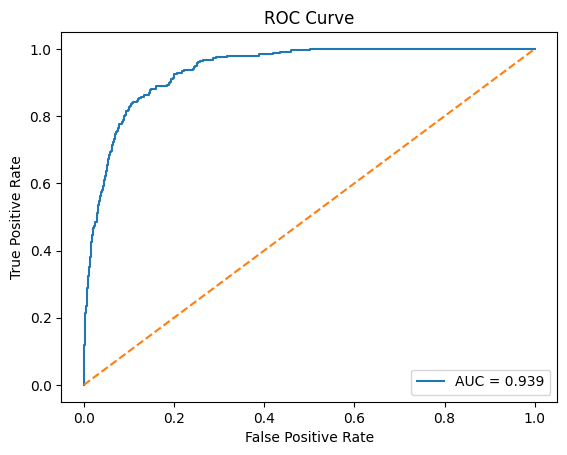

In [9]:
result = Oligoclonal.predict(test_rows)
df = Oligoclonal.evaluate(result,threshold=0.6)